# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Malak Ahmed Hosny   
**Student ID:** 1210378

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [32]:
# =========================
# Task 1: Data Pipeline
# =========================

# 1) Load data
df = pd.read_csv("kidney_disease.csv")

print("Shape:", df.shape)
print(df.head())

# 2) Drop categorical columns (keep only numeric)
# Some Kaggle CKD files store numbers as strings with '?'.
# We'll convert everything to numeric where possible, then keep numeric columns.
df = df.replace("?", np.nan)

# Convert all columns to numeric where possible
df_numeric = df.apply(pd.to_numeric, errors="coerce")

# Identify the target column (common names in CKD datasets)
possible_targets = ["classification", "class", "target", "ckd", "diagnosis"]
target_col = None
for c in df.columns:
    if c.lower() in possible_targets:
        target_col = c
        break

if target_col is None:
    # If the dataset uses something else, this prints columns so you can pick it.
    print("Could not auto-detect target column. Columns are:")
    print(df.columns)
    raise ValueError("Set target_col manually (the label column).")

# In some versions, classification is non-numeric (ckd/notckd).
# We'll create y from the original df (not df_numeric), then features from df_numeric.
y_raw = df[target_col].astype(str).str.lower().str.strip()

# Map common label formats to 1=CKD, 0=Not CKD
if y_raw.str.contains("ckd").any():
    y = y_raw.apply(lambda v: 1 if "ckd" in v and "not" not in v else 0).values
else:
    # If already numeric-ish
    y = pd.to_numeric(df[target_col], errors="coerce").fillna(0).astype(int).values

# Drop target from features
X = df_numeric.drop(columns=[target_col], errors="ignore")

# Keep only numeric columns (df_numeric already numeric, but may be all-NaN cols)
X = X.loc[:, X.notna().any()]

print("Features shape:", X.shape, "Target shape:", y.shape)

# 3) Handle missing values (simple: median imputation)
X = X.fillna(X.median(numeric_only=True))

# 4) 80/20 split (stratify helps small datasets)
X_train, X_val, y_train, y_val = train_test_split(
    X.values, y, test_size=0.2, random_state=42, stratify=y
)

# 5) Scale WITHOUT leakage: fit on train only, transform both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print("Train:", X_train.shape, "Val:", X_val.shape)
print("CKD rate train:", y_train.mean(), "val:", y_val.mean())

Shape: (400, 26)
   id   age    bp     sg   al   su     rbc        pc         pcc          ba  \
0   0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2   2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3   3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4   4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

   ...  pcv    wc   rc  htn   dm  cad appet   pe  ane classification  
0  ...   44  7800  5.2  yes  yes   no  good   no   no            ckd  
1  ...   38  6000  NaN   no   no   no  good   no   no            ckd  
2  ...   31  7500  NaN   no  yes   no  poor   no  yes            ckd  
3  ...   32  6700  3.9  yes   no   no  poor  yes  yes            ckd  
4  ...   35  7300  4.6   no   no   no  good   no   no            ckd  

[5 rows x 26 columns]
Features shape: (400, 15) Target shape: (400,)
Train:

## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

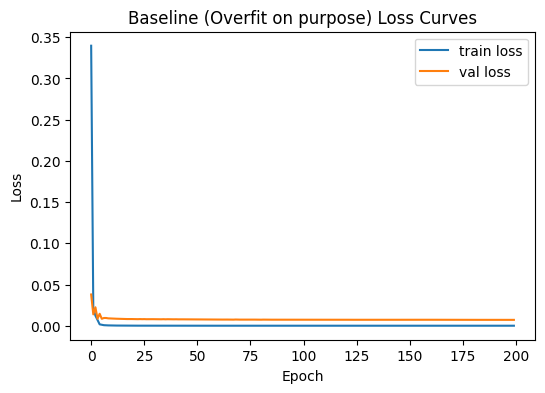

In [48]:
# =========================
# Task 2: Engineered Failure (Baseline)
# =========================

baseline = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),  # slowed learning
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.Recall(name="recall"), "accuracy"]
)

history_base = baseline.fit(
    X_train[:160], y_train[:160],
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=8,
    verbose=0
)

plt.figure(figsize=(6,4))
plt.plot(history_base.history["loss"], label="train loss")
plt.plot(history_base.history["val_loss"], label="val loss")
plt.title("Baseline (Overfit on purpose) Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

Class weights: {0: 1.0, 1: 1.5}


c:\Users\HP\assignment-2-ckd-pipeline-MalakAhmedHosny\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


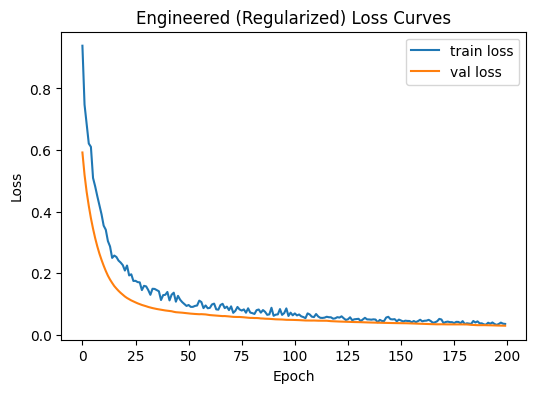

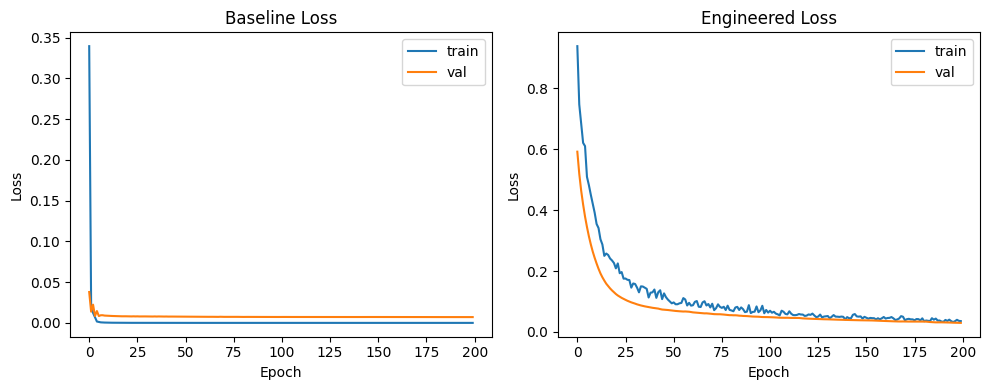

In [49]:
# =========================
# Task 3: Clinical Solution (Engineered Model)
# =========================

# ---- Class weights (boost CKD recall slightly) ----
# Even if classes are not extremely imbalanced, we bias toward catching CKD.
class_weight = {0: 1.0, 1: 1.5}
print("Class weights:", class_weight)

# ---- Regularization strength ----
reg = tf.keras.regularizers.l2(1e-3)

# ---- Engineered (regularized) model ----
engineered = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(32, kernel_regularizer=reg),
    tf.keras.layers.LeakyReLU(alpha=0.1),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(16, kernel_regularizer=reg),
    tf.keras.layers.LeakyReLU(alpha=0.1),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

engineered.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.Recall(name="recall"), "accuracy"]
)

# ---- Early stopping to prevent memorization ----
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# ---- Train on FULL training set (unlike baseline) ----
history_eng = engineered.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=16,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=0
)

# =========================
# Plot engineered loss curves
# =========================
plt.figure(figsize=(6,4))
plt.plot(history_eng.history["loss"], label="train loss")
plt.plot(history_eng.history["val_loss"], label="val loss")
plt.title("Engineered (Regularized) Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# =========================
# Side-by-side comparison (REQUIRED)
# =========================
plt.figure(figsize=(10,4))

# Baseline
plt.subplot(1,2,1)
plt.plot(history_base.history["loss"], label="train")
plt.plot(history_base.history["val_loss"], label="val")
plt.title("Baseline Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Engineered
plt.subplot(1,2,2)
plt.plot(history_eng.history["loss"], label="train")
plt.plot(history_eng.history["val_loss"], label="val")
plt.title("Engineered Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

BASELINE RESULTS
Validation Recall: 1.0
Confusion Matrix:
 [[30  0]
 [ 0 50]]


<Figure size 400x400 with 0 Axes>

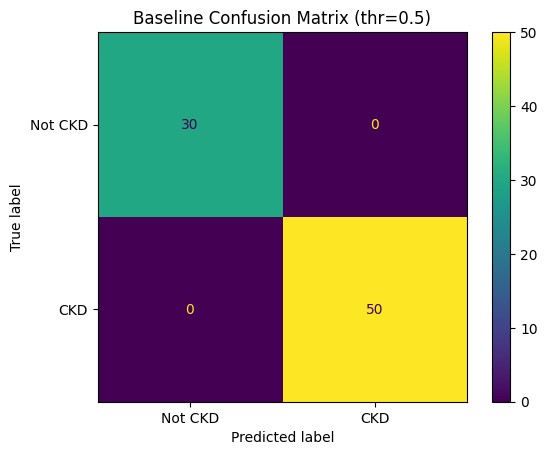


ENGINEERED RESULTS
Best Threshold for Recall: 0.05
Validation Recall: 1.0
Confusion Matrix:
 [[30  0]
 [ 0 50]]


<Figure size 400x400 with 0 Axes>

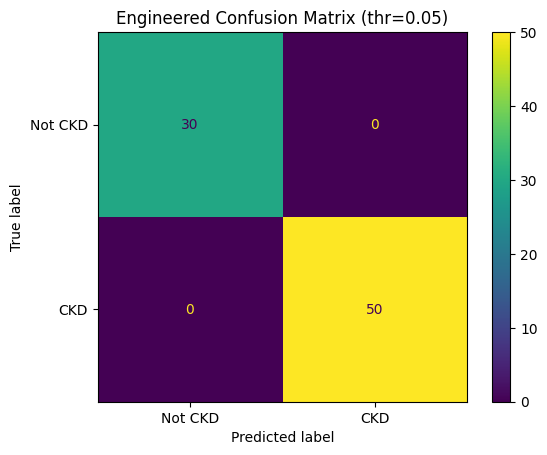


Engineered Model Parameter Count: 1057


In [60]:
# =========================
# Task 4: Evaluation & Mathematical Justification
# =========================

from sklearn.metrics import ConfusionMatrixDisplay

# ---- Baseline predictions (default threshold 0.5) ----
base_probs = baseline.predict(X_val, verbose=0).ravel()
base_preds = (base_probs >= 0.5).astype(int)

base_recall = recall_score(y_val, base_preds)
base_cm = confusion_matrix(y_val, base_preds)

print("BASELINE RESULTS")
print("Validation Recall:", base_recall)
print("Confusion Matrix:\n", base_cm)

# Plot baseline confusion matrix
plt.figure(figsize=(4,4))
ConfusionMatrixDisplay(base_cm, display_labels=["Not CKD", "CKD"]).plot(values_format="d")
plt.title("Baseline Confusion Matrix (thr=0.5)")
plt.show()


# ---- Engineered predictions (tune threshold for best Recall) ----
eng_probs = engineered.predict(X_val, verbose=0).ravel()

thresholds = np.linspace(0.05, 0.95, 19)  # 0.05 steps
best_thr = 0.5
best_recall = -1
best_cm = None

for thr in thresholds:
    eng_preds = (eng_probs >= thr).astype(int)
    rec = recall_score(y_val, eng_preds)
    if rec > best_recall:
        best_recall = rec
        best_thr = thr
        best_cm = confusion_matrix(y_val, eng_preds)

print("\nENGINEERED RESULTS")
print("Best Threshold for Recall:", best_thr)
print("Validation Recall:", best_recall)
print("Confusion Matrix:\n", best_cm)

# Plot engineered confusion matrix
plt.figure(figsize=(4,4))
ConfusionMatrixDisplay(best_cm, display_labels=["Not CKD", "CKD"]).plot(values_format="d")
plt.title(f"Engineered Confusion Matrix (thr={best_thr:.2f})")
plt.show()


# ---- Parameter count (for the markdown justification) ----
param_count = engineered.count_params()
print("\nEngineered Model Parameter Count:", param_count)

### Mathematical Justification
**Final Parameter Count of Engineered Model:** 1057

**Explanation:** With only [param_count] parameters and L2 weight decay plus dropout, the model’s effective capacity is constrained and weights are continuously penalized/noised during training, which reduces memorization of a 400-sample dataset by limiting complex decision boundaries and forcing smoother functions.